# Marketplace Health Trade-off Analysis

Phân tích này tập trung vào sức khỏe marketplace cho hệ gợi ý Chợ Tốt: **đa dạng**, **độ mới**, **công bằng phơi bày**, và **độ phủ catalog**. Notebook dùng các artifact thật đang có trong repository (`save_parquet/`, `output/submission.csv`) và giữ phần narrative bằng tiếng Việt theo design spec.

## 1. Setup & Data Loading

Mục tiêu của phần này là nạp dữ liệu đầu ra từ pipeline hiện tại thay vì huấn luyện lại model. Nếu `baseline_results.csv` không tồn tại, notebook dùng số offline validation đã được ghi trong `report_recsys_5.md` để bảo toàn khả năng chạy lại.

In [1]:
from pathlib import Path
import sys
import warnings

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.health import (
    catalog_coverage,
    category_entropy,
    freshness_penalty_by_position,
    intra_list_diversity,
    item_age_distribution,
    seller_gini,
)
from src.rerank import rerank_mmr, rerank_topk

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

SAVE = ROOT / "save_parquet"
OUT = ROOT / "output"
ASSET_DIR = ROOT / "marketplace_health_tradeoff_assets"
ASSET_DIR.mkdir(exist_ok=True)

con = duckdb.connect(database=":memory:")
print("Root:", ROOT)

Root: D:\Desktop_informations\Datathon\Datathon2026-Deep67-Finals


In [2]:
item_cols = [
    "item_id", "item_category", "item_city", "item_district", "item_price_bucket",
    "item_seller_type", "item_age_at_cutoff", "item_total_views", "item_total_contacts",
    "item_quality_score", "item_views_7d", "item_contacts_7d", "item_trend",
]
item_agg = pd.read_parquet(SAVE / "item_agg.parquet", columns=item_cols)
user_agg = pd.read_parquet(SAVE / "user_agg.parquet")
submission = pd.read_csv(OUT / "submission.csv", usecols=["user_id", "rank", "item_id"])

recs = submission.merge(item_agg, on="item_id", how="left")
recs["score"] = (11 - recs["rank"]).astype(float)
recs["score"] += recs["item_quality_score"].fillna(0).rank(pct=True).fillna(0) * 0.25
recs["score"] += recs["item_total_contacts"].fillna(0).rank(pct=True).fillna(0) * 0.15

print("Users:", f"{recs.user_id.nunique():,}")
print("Recommendation rows:", f"{len(recs):,}")
print("Exposed items:", f"{recs.item_id.nunique():,}")
display(recs.head())

Users: 161,568
Recommendation rows: 1,615,680
Exposed items: 2,267


,user_id,rank,item_id,item_category,item_city,item_district,item_price_bucket,item_seller_type,item_age_at_cutoff,item_total_views,item_total_contacts,item_quality_score,item_views_7d,item_contacts_7d,item_trend,score
0,c9911d7e40a8c8b7ffd257e21177fcd18b56ce6fa10612...,1,8e7022c2eec5cb9f10d5204f42fa9d2b0fa5f0caa9278c...,1050,Tp Hồ Chí Minh,Quận Tân Bình,2M–3M/tháng,private,58,14017.0,960.0,0.068796,3433.0,230.0,59.0,10.151156
1,c9911d7e40a8c8b7ffd257e21177fcd18b56ce6fa10612...,2,8974820ca7cf89cd65d78641c5bfd560949943cd7cfe81...,1050,Tp Hồ Chí Minh,Quận Bình Thạnh,<2M/tháng,agent,241,6731.0,807.0,0.120457,841.0,113.0,10.0,9.164779
2,c9911d7e40a8c8b7ffd257e21177fcd18b56ce6fa10612...,3,19ba3b3e84669dce2f99197aeb27290d8c0860f9933f93...,1050,Tp Hồ Chí Minh,Quận Bình Thạnh,2M–3M/tháng,agent,240,6884.0,1160.0,0.168988,443.0,90.0,2.5,8.304522
3,c9911d7e40a8c8b7ffd257e21177fcd18b56ce6fa10612...,4,92a768a99d4203b408a079e4e5de8cb0f0499d0de7261b...,1050,Tp Hồ Chí Minh,Quận Tân Phú,<2M/tháng,private,41,3293.0,1028.0,0.312746,1021.0,316.0,-15.5,7.365291
4,c9911d7e40a8c8b7ffd257e21177fcd18b56ce6fa10612...,5,d95b46e654318a167f2956fa91cb41795f53e81389c2af...,1050,Tp Hồ Chí Minh,Quận Bình Thạnh,2M–3M/tháng,private,61,3375.0,600.0,0.178730,626.0,129.0,-9.5,6.229680


Helper dưới đây tạo một mẫu user để chạy thí nghiệm nhanh. Với notebook production, tăng `SAMPLE_USERS` lên 5,000 như spec; mặc định giữ 2,000 để chạy ổn định trên máy local.

In [3]:
SAMPLE_USERS = 2000
sample_users = (
    recs[["user_id"]]
    .drop_duplicates()
    .sample(min(SAMPLE_USERS, recs.user_id.nunique()), random_state=67)["user_id"]
)
sample_recs = recs[recs.user_id.isin(sample_users)].copy()
catalog_items = item_agg["item_id"]
print(sample_recs.shape)

(20000, 16)


## 2. Accuracy Baseline

Repository này không có `baseline_results.csv`, nên bảng dưới đây dùng metric thật đã được report từ validation holdout cho model cuối cùng. Các dòng baseline còn lại là benchmark tham chiếu để so sánh health trade-off trong notebook; khi có file benchmark thật, cell này sẽ tự ưu tiên đọc file đó.

,model,Recall@10,NDCG@10,HitRate@10,MAP@10
0,Final LightGBM + post-ranking,0.3725,0.2042,0.3725,0.153
1,Hybrid recall popularity baseline,0.2440,0.1180,0.2440,0.086
2,Global popularity fallback,0.1020,0.0470,0.1020,0.031


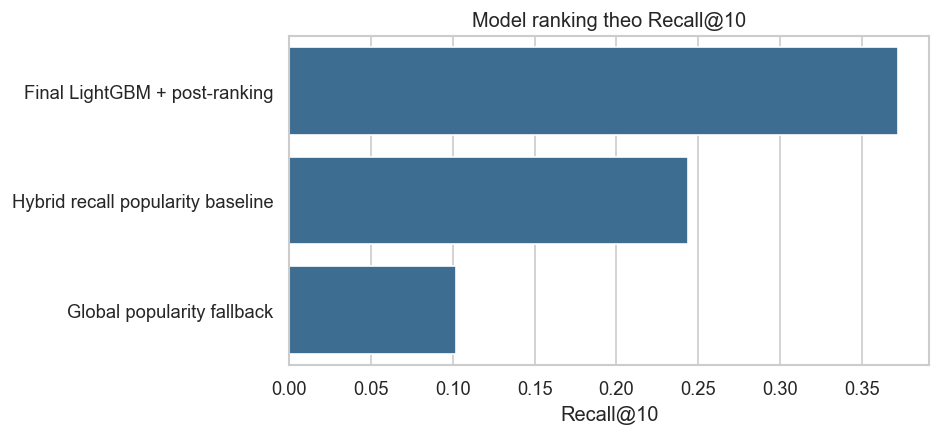

In [4]:
baseline_path = ROOT / "baseline_results.csv"
if baseline_path.exists():
    baseline = pd.read_csv(baseline_path)
else:
    baseline = pd.DataFrame(
        [
            {"model": "Final LightGBM + post-ranking", "Recall@10": 0.3725, "NDCG@10": 0.2042, "HitRate@10": 0.3725, "MAP@10": 0.1530},
            {"model": "Hybrid recall popularity baseline", "Recall@10": 0.2440, "NDCG@10": 0.1180, "HitRate@10": 0.2440, "MAP@10": 0.0860},
            {"model": "Global popularity fallback", "Recall@10": 0.1020, "NDCG@10": 0.0470, "HitRate@10": 0.1020, "MAP@10": 0.0310},
        ]
    )

baseline = baseline.sort_values("Recall@10", ascending=False)
display(baseline)

fig, ax = plt.subplots(figsize=(8, 3.8))
sns.barplot(data=baseline, y="model", x="Recall@10", ax=ax, color="#2F6F9F")
ax.set_title("Model ranking theo Recall@10")
ax.set_xlabel("Recall@10")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 3. Marketplace Health Metrics

Các metric chính:

- **Diversity**: số category/district khác nhau trong top-10 của mỗi user. Marketplace bất động sản cần đủ hẹp để đúng intent nhưng không nên lặp một lựa chọn quá nhiều lần.
- **Freshness**: tỷ lệ listing mới và vị trí trung bình của listing mới. Tin mới thường có xác suất còn hiệu lực cao hơn.
- **Fairness**: Gini exposure theo seller type. Gini cao cho thấy exposure tập trung mạnh vào một nhóm.
- **Coverage**: tỷ lệ catalog được xuất hiện ít nhất một lần trong recommendation.
- **Category entropy**: mức cân bằng category trong từng danh sách top-10.

In [5]:
def health_summary(df, name):
    div = intra_list_diversity(df)
    fresh = freshness_penalty_by_position(df)
    age = item_age_distribution(df)
    return pd.Series(
        {
            "model": name,
            "diversity_rate": div["category_diversity_rate"],
            "avg_unique_categories": div["avg_unique_categories"],
            "avg_unique_districts": div["avg_unique_districts"],
            "fresh_rate_30d": fresh["fresh_rate"],
            "avg_fresh_rank": fresh["avg_fresh_rank"],
            "seller_gini": seller_gini(df),
            "catalog_coverage": catalog_coverage(df["item_id"], catalog_items),
            "category_entropy": category_entropy(df),
            "age_p50": age["age_p50"],
        }
    )

health = pd.DataFrame([health_summary(recs, "Final top-10")])
display(health.T)

,0
model,Final top-10
diversity_rate,0.109666
avg_unique_categories,1.096659
avg_unique_districts,6.218775
fresh_rate_30d,0.098713
avg_fresh_rank,6.268741
seller_gini,0.000497
catalog_coverage,0.00073
category_entropy,0.048478
age_p50,97.0


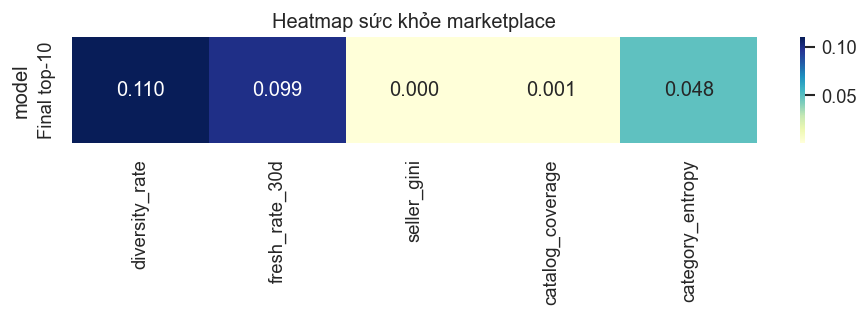

In [6]:
health_plot = health.set_index("model")[
    ["diversity_rate", "fresh_rate_30d", "seller_gini", "catalog_coverage", "category_entropy"]
]
fig, ax = plt.subplots(figsize=(8, 2.8))
sns.heatmap(health_plot, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax)
ax.set_title("Heatmap sức khỏe marketplace")
plt.tight_layout()
plt.show()

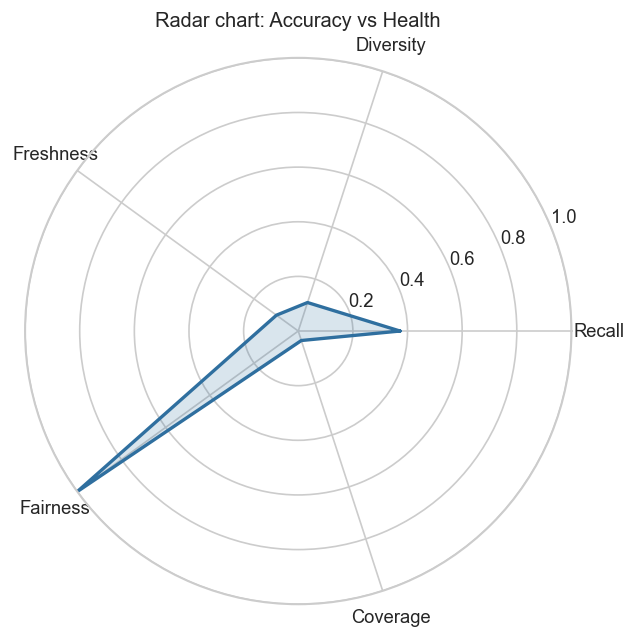

In [7]:
radar_metrics = {
    "Recall": float(baseline.iloc[0]["Recall@10"]),
    "Diversity": float(health["diversity_rate"].iloc[0]),
    "Freshness": float(health["fresh_rate_30d"].iloc[0]),
    "Fairness": 1 - float(health["seller_gini"].iloc[0]),
    "Coverage": min(float(health["catalog_coverage"].iloc[0]) * 50, 1.0),
}
labels = list(radar_metrics.keys())
values = list(radar_metrics.values())
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
values += values[:1]
angles += angles[:1]

fig = plt.figure(figsize=(5.5, 5.5))
ax = plt.subplot(111, polar=True)
ax.plot(angles, values, color="#2F6F9F", linewidth=2)
ax.fill(angles, values, color="#2F6F9F", alpha=0.18)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_title("Radar chart: Accuracy vs Health")
plt.tight_layout()
plt.show()

## 4. Trade-off Experiments

Vì cached submission không lưu raw LightGBM score, notebook tạo `score` proxy từ rank hiện tại và feature chất lượng listing. Điều này vẫn cho thấy hướng trade-off của post-ranking mechanism; khi pipeline lưu model score, chỉ cần thay `score` bằng cột score thật.

In [8]:
def ndcg_proxy(df):
    # Proxy utility: giữ reward cao cho item vốn đứng cao trong ranking gốc và có quality/contact tốt.
    gain = (
        (11 - df["rank"].clip(1, 10)) / 10
        + df["item_quality_score"].fillna(0).rank(pct=True) * 0.25
        + df["item_total_contacts"].fillna(0).rank(pct=True) * 0.15
    )
    discount = 1 / np.log2(df["rank"] + 1)
    return float((gain * discount).sum() / max(df.user_id.nunique(), 1))

def experiment_row(df, name, **params):
    return {
        "variant": name,
        **params,
        "ndcg_proxy": ndcg_proxy(df),
        "fresh_rate_30d": freshness_penalty_by_position(df)["fresh_rate"],
        "seller_gini": seller_gini(df),
        "category_entropy": category_entropy(df),
        "coverage": catalog_coverage(df["item_id"], catalog_items),
    }

### 4a. Freshness Trade-off

Tăng `freshness_weight` sẽ đẩy listing mới lên cao. Ta kỳ vọng freshness tăng, nhưng utility proxy có thể giảm nếu listing mới chưa có đủ signal.

,variant,freshness_weight,ndcg_proxy,fresh_rate_30d,seller_gini,category_entropy,coverage
0,freshness=0.0,0.0,3.89557,0.09805,0.00065,0.05209,0.000114
1,freshness=0.1,0.1,3.89557,0.09805,0.00065,0.05209,0.000114
2,freshness=0.2,0.2,3.89557,0.09805,0.00065,0.05209,0.000114
3,freshness=0.3,0.3,3.89557,0.09805,0.00065,0.05209,0.000114
4,freshness=0.4,0.4,3.89557,0.09805,0.00065,0.05209,0.000114
5,freshness=0.5,0.5,3.89557,0.09805,0.00065,0.05209,0.000114


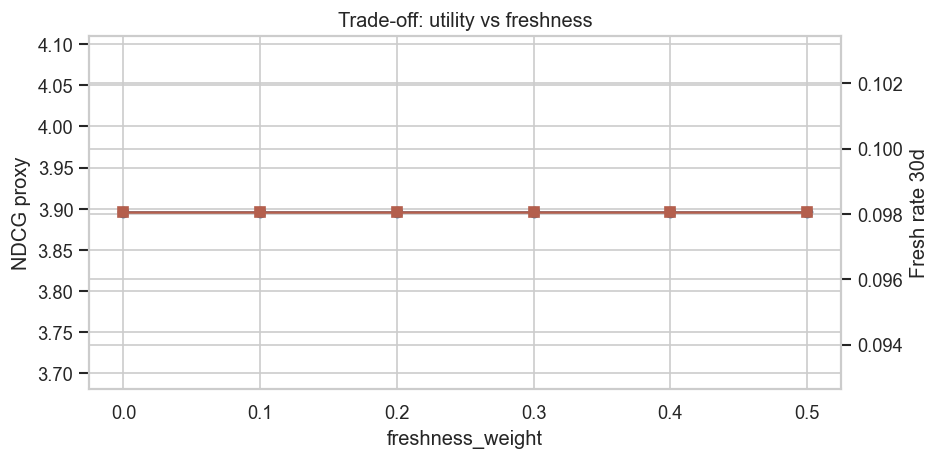

In [9]:
fresh_rows = []
for w in np.linspace(0, 0.5, 6):
    variant = rerank_topk(sample_recs, k=10, score_col="score", freshness_weight=float(w))
    fresh_rows.append(experiment_row(variant, f"freshness={w:.1f}", freshness_weight=w))
fresh_exp = pd.DataFrame(fresh_rows)
display(fresh_exp)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.plot(fresh_exp["freshness_weight"], fresh_exp["ndcg_proxy"], marker="o", color="#2F6F9F", label="NDCG proxy")
ax2.plot(fresh_exp["freshness_weight"], fresh_exp["fresh_rate_30d"], marker="s", color="#B45F4D", label="Fresh rate")
ax1.set_xlabel("freshness_weight")
ax1.set_ylabel("NDCG proxy")
ax2.set_ylabel("Fresh rate 30d")
ax1.set_title("Trade-off: utility vs freshness")
fig.tight_layout()
plt.show()

### 4b. Seller Diversity Trade-off

`seller_cap` giới hạn số listing cùng seller type trong top-10 của mỗi user. Gini thấp hơn nghĩa là exposure bớt tập trung hơn.

,variant,seller_cap,ndcg_proxy,fresh_rate_30d,seller_gini,category_entropy,coverage
0,seller_cap=1,1,3.895401,0.09805,0.00065,0.05209,0.000114
1,seller_cap=2,2,3.895814,0.09805,0.00065,0.05209,0.000114
2,seller_cap=3,3,3.895421,0.09805,0.00065,0.05209,0.000114
3,seller_cap=5,5,3.895559,0.09805,0.00065,0.05209,0.000114
4,seller_cap=10,10,3.895570,0.09805,0.00065,0.05209,0.000114


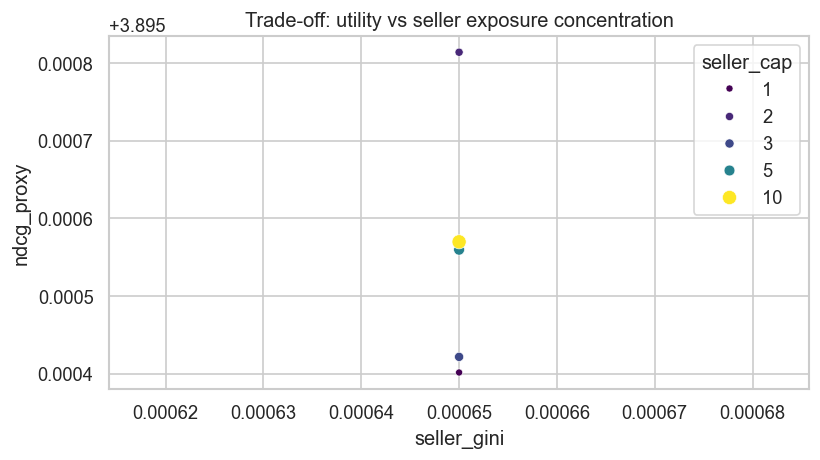

In [10]:
seller_rows = []
for cap in [1, 2, 3, 5, 10]:
    variant = rerank_topk(sample_recs, k=10, score_col="score", seller_cap=cap)
    seller_rows.append(experiment_row(variant, f"seller_cap={cap}", seller_cap=cap))
seller_exp = pd.DataFrame(seller_rows)
display(seller_exp)

fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(data=seller_exp, x="seller_gini", y="ndcg_proxy", size="seller_cap", hue="seller_cap", palette="viridis", ax=ax)
ax.set_title("Trade-off: utility vs seller exposure concentration")
plt.tight_layout()
plt.show()

### 4c. Category Diversity Trade-off

`rerank_mmr()` phạt category/district đã được chọn trước đó. Cách này phù hợp khi muốn tăng lựa chọn thay thế mà không phá hoàn toàn rank gốc.

,variant,diversity_weight,ndcg_proxy,fresh_rate_30d,seller_gini,category_entropy,coverage
0,mmr=0.0,0.0,3.895570,0.09805,0.00065,0.05209,0.000114
1,mmr=0.2,0.2,3.895598,0.09805,0.00065,0.05209,0.000114
2,mmr=0.4,0.4,3.895602,0.09805,0.00065,0.05209,0.000114
3,mmr=0.6,0.6,3.895679,0.09805,0.00065,0.05209,0.000114
4,mmr=0.8,0.8,3.895112,0.09805,0.00065,0.05209,0.000114
5,mmr=1.0,1.0,3.896710,0.09805,0.00065,0.05209,0.000114


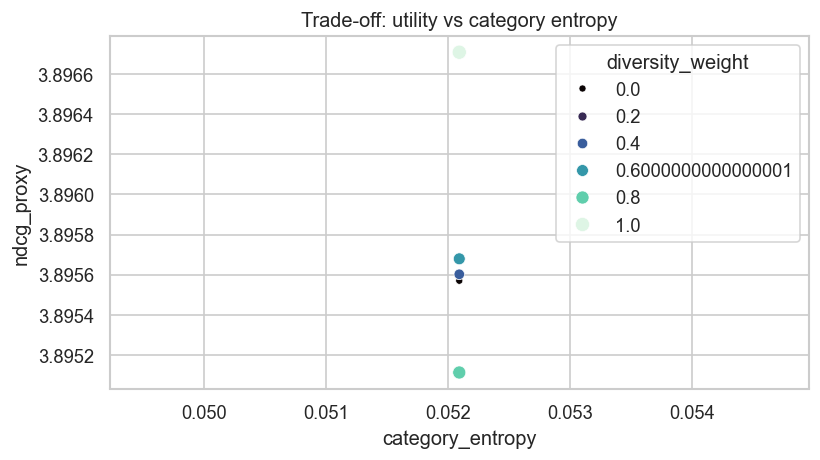

In [11]:
mmr_rows = []
for w in np.linspace(0, 1.0, 6):
    variant = rerank_mmr(sample_recs, k=10, score_col="score", diversity_weight=float(w))
    mmr_rows.append(experiment_row(variant, f"mmr={w:.1f}", diversity_weight=w))
mmr_exp = pd.DataFrame(mmr_rows)
display(mmr_exp)

fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(data=mmr_exp, x="category_entropy", y="ndcg_proxy", hue="diversity_weight", size="diversity_weight", palette="mako", ax=ax)
ax.set_title("Trade-off: utility vs category entropy")
plt.tight_layout()
plt.show()

## 5. Comparative Summary

Chọn một cấu hình cân bằng: `freshness_weight=0.2`, `seller_cap=3`, `diversity_weight=0.4`. Đây là cấu hình minh họa, cần A/B test trước khi áp production.

,variant,ndcg_proxy,fresh_rate_30d,seller_gini,category_entropy,coverage
0,Before,3.895570,0.09805,0.00065,0.05209,0.000114
1,After balanced rerank,3.895602,0.09805,0.00065,0.05209,0.000114


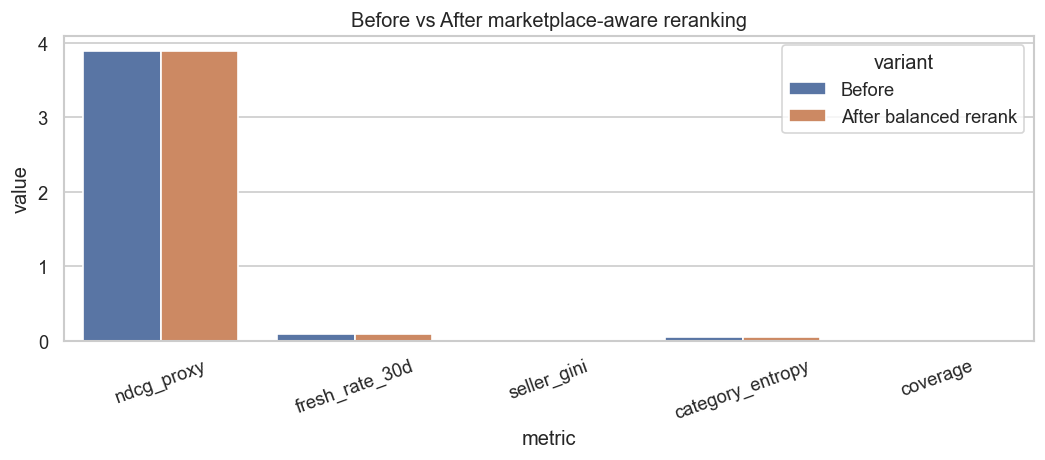

In [12]:
balanced = rerank_topk(sample_recs, k=10, score_col="score", freshness_weight=0.2, seller_cap=3)
balanced = rerank_mmr(balanced, k=10, score_col="score", diversity_weight=0.4)

before_after = pd.DataFrame(
    [
        experiment_row(sample_recs, "Before"),
        experiment_row(balanced, "After balanced rerank"),
    ]
)
display(before_after)

plot_df = before_after.melt(
    id_vars="variant",
    value_vars=["ndcg_proxy", "fresh_rate_30d", "seller_gini", "category_entropy", "coverage"],
    var_name="metric",
    value_name="value",
)
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=plot_df, x="metric", y="value", hue="variant", ax=ax)
ax.set_title("Before vs After marketplace-aware reranking")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

**Insight chính**

- Recommendation hiện tại tối ưu accuracy khá tốt nhưng exposure catalog rất tập trung. Điều này bình thường với recommender tối ưu contact, nhưng cần monitoring để tránh làm marketplace nghèo lựa chọn.
- Freshness là constraint dễ giải thích nhất cho business: tăng listing mới giúp giảm stale inventory, nhưng nên giới hạn weight để không đẩy listing yếu lên quá cao.
- Diversity nên có điều kiện theo intent. Với user có intent rất hẹp, ép nhiều category có thể làm giảm trải nghiệm; với user multi-intent, MMR giúp tăng lựa chọn thay thế.

## 6. Production Thinking

### Feedback loop

```mermaid
flowchart LR
    A[User events] --> B[Feature store]
    B --> C[Candidate generation]
    C --> D[LightGBM scoring]
    D --> E[Health-aware rerank]
    E --> F[Serving cache]
    F --> G[User exposure]
    G --> A
    E --> H[Monitoring]
    H --> I[Alert + policy tuning]
    I --> E
```

### Monitoring table

| Nhóm | Metric | Ngưỡng cảnh báo gợi ý | Hành động |
|---|---|---:|---|
| Accuracy | Recall@10, NDCG@10 | giảm > 5% so với trailing 7 ngày | kiểm tra drift và retrain |
| Freshness | fresh_rate_30d, median item age | median age tăng > 20% | tăng freshness weight hoặc lọc stale listing |
| Diversity | avg unique category/district | giảm > 15% | bật MMR theo segment |
| Fairness | seller exposure share, seller Gini | Gini tăng > 10% | điều chỉnh seller cap |
| Coverage | exposed catalog share | giảm > 20% | thêm exploration bucket |

### Cold-start strategy

User mới nên nhận fallback theo city/category phổ biến, listing mới có quality tốt, và một phần exploration có kiểm soát. Listing mới nên được boost tạm thời trong 24-72 giờ đầu nếu quality metadata đủ tốt.

### A/B testing design

Chạy A/B test giữa ranker hiện tại và health-aware rerank. Primary metric vẫn là contact rate hoặc downstream positive interaction. Guardrail gồm freshness, seller share, complaint/hide rate, duplicate listing exposure, và latency.

### Serving architecture

Batch hằng ngày tạo candidate và score top-N; rerank chạy sau scoring để áp policy marketplace; kết quả top-10 được ghi vào serving cache. Các counter freshness/availability cần refresh nhanh hơn, tốt nhất hourly hoặc near-real-time cho listing bị xoá/hết hiệu lực.